In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader

seq_len = 16
loader = CopyPasteDataLoader(vocab_size=16, max_token=10, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

#### Hypothesis 1. 
- off-policy distillation improves 'search_adv' while maintaining 'vocab_util'
$$
a_{p} \sim \hat{p}_{\theta_{p}}(a | s), \quad \theta_{child} = \arg \min_{\theta} \mathcal{L}(s, a_{p})
$$
(a). initialize $\theta_{child} \sim \mathcal{N}(0, 1)$ || this provably enhance 'search_advantage' while inheriting the 'vocab_utilization', however, it necessitate learning 'traj_perplexity' from scratch, doubling the compute required. 

(b). initialize $\theta_{child} = \theta$ || this could inherit the 'traj perplexity' and saves efforts, it serves to enhance the 'search_advantage' whilst keeping 'vocab_utilization' & 'traj_perplexity' un-changed. 

In [ ]:
from sorl.neo_utils import sorl_search, sorl_search_v2, compute_loss, sorl_evaluate, compute_vocab_utilization_rate
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_sel = 0.0
sel_mode = "abs_ppt"
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 4 
temperatures_eval = torch.tensor([min_temperature, max_temperature, max_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 
    if vocab_util < 0.5:
        alpha_loss = - 0.1 # encourage vocab utilization
        alpha_sel = 0.1
    else: 
        alpha_loss = 0.1 # encourage search_adv

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                               truncate_seq_len=False, alpha_select=alpha_sel, select_mode=sel_mode)
        print(f" - training search_adv: {search_adv.item() * 100:.2f}%")
    # --- compute loss ---
    traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)    
                                       
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature, max_temperature, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['alpha_loss'].append(alpha_loss)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | alpha_loss: {alpha_loss:.2f}")

 - training search_adv: 0.00%
validation step 0 | traj_loss: 3.25 | abs_loss: 3.28 | search adv: 0.02% | vocab util: 83.33% | alpha_loss: 0.10
 - training search_adv: 0.09%
 - training search_adv: 0.13%
validation step 2 | traj_loss: 3.12 | abs_loss: 3.27 | search adv: 0.03% | vocab util: 83.33% | alpha_loss: 0.10
 - training search_adv: 0.20%
 - training search_adv: 0.23%
validation step 4 | traj_loss: 2.87 | abs_loss: 3.38 | search adv: 0.25% | vocab util: 50.00% | alpha_loss: 0.10
 - training search_adv: 0.15%
 - training search_adv: 0.12%
validation step 6 | traj_loss: 2.69 | abs_loss: 3.39 | search adv: 0.06% | vocab util: 16.67% | alpha_loss: 0.10
 - training search_adv: 3.58%
 - training search_adv: 3.83%
validation step 8 | traj_loss: 2.57 | abs_loss: 3.54 | search adv: 0.02% | vocab util: 16.67% | alpha_loss: -0.10
 - training search_adv: 4.09%
 - training search_adv: 4.33%
validation step 10 | traj_loss: 2.48 | abs_loss: 3.81 | search adv: 0.00% | vocab util: 16.67% | alpha_l

In [3]:
from sorl.neo_utils import sorl_search_v3, compute_grpo_loss_v2, sorl_evaluate, compute_vocab_utilization_rate, compute_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------- GSPO style SoRL || Train on all rollouts -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_sel = 0.0
alpha_loss = -0.1
sel_mode = "abs_ppt"
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 4 
temperatures_eval = torch.tensor([min_temperature, max_temperature, max_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 
    if vocab_util < 0.5:
        alpha_loss = - 0.1 # encourage vocab utilization
        alpha_sel = 0.1
    else: 
        alpha_loss = 0.1 # encourage search_adv

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v3(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                               truncate_seq_len=False)
        # with_adv_ratio = (torch.abs(search_adv) > 1e-1).sum() / search_adv.numel()
        # print(f"Ratio of tokens with meaningful advantage (non-clipped): {with_adv_ratio * 100:.2f}%")
        # print(f" - training token adv mean : {search_adv.mean().item() * 100:.2f}% | std: {search_adv.std().item() * 100:.2f}%")
    # --- compute loss ---
    traj_loss, grpo_loss = compute_grpo_loss_v2(search_tokens, search_ppt, search_adv, model, memory_span, attn_blocksize)    
                                       
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * grpo_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature, max_temperature, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['alpha_loss'].append(alpha_loss)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | alpha_loss: {alpha_loss:.2f}")

validation step 0 | traj_loss: 3.25 | abs_loss: 3.31 | search adv: 0.01% | vocab util: 83.33% | alpha_loss: 0.10
validation step 2 | traj_loss: 3.09 | abs_loss: 3.43 | search adv: 0.06% | vocab util: 66.67% | alpha_loss: 0.10
validation step 4 | traj_loss: 2.85 | abs_loss: 3.70 | search adv: 0.03% | vocab util: 50.00% | alpha_loss: 0.10
validation step 6 | traj_loss: 2.65 | abs_loss: 4.05 | search adv: 0.03% | vocab util: 33.33% | alpha_loss: 0.10
validation step 8 | traj_loss: 2.53 | abs_loss: 4.39 | search adv: 0.03% | vocab util: 16.67% | alpha_loss: -0.10
validation step 10 | traj_loss: 2.45 | abs_loss: 4.70 | search adv: 0.01% | vocab util: 16.67% | alpha_loss: -0.10
validation step 12 | traj_loss: 2.41 | abs_loss: 4.99 | search adv: 0.00% | vocab util: 16.67% | alpha_loss: -0.10
validation step 14 | traj_loss: 2.37 | abs_loss: 5.25 | search adv: 0.01% | vocab util: 16.67% | alpha_loss: -0.10
validation step 16 | traj_loss: 2.35 | abs_loss: 5.46 | search adv: 0.00% | vocab util: 1

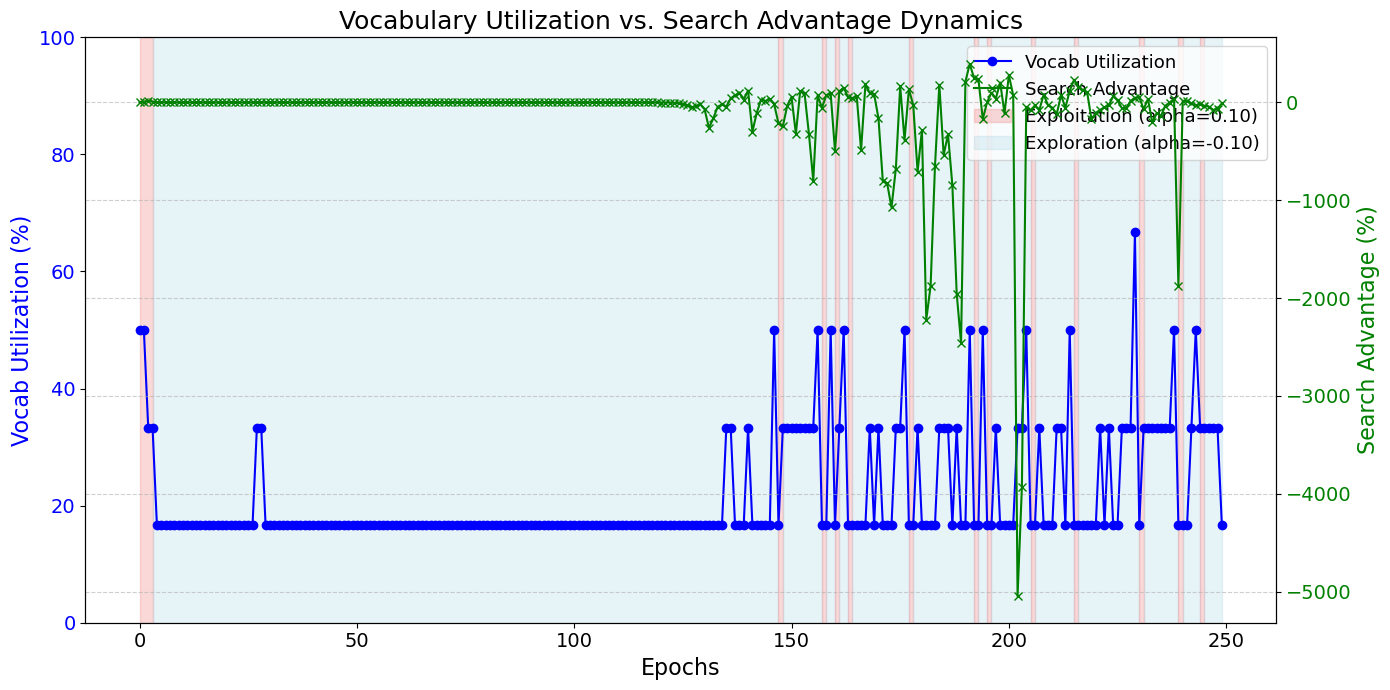

In [ ]:
# Help visualize the 'search adv' & 'vocab util' dynamics
from sorl.stat import plot_training_dynamics
# include 'alpha_sel=-0.1' to force picking rare abstraction?
plot_training_dynamics(record)

Question: Can we obtain un-collapsed vocab utilization at $t_{1} = 0.0$?

Answer: Yes we can, empirically, we observe 'vocab util: $>50.0\%$' when $t_{eval} = 0.0$. Therefore, we could've used $t_{eval}=0.0$ as the criterion to decide phase change, since this would ensure we stop at a position where greedy vocab utilization rate is not collapsed. 

Observation: On another run, we observe that despite ~300 steps of (Phase I) runs with $\alpha=-0.1$ that encourage exploration, we are unable to increase the greedy vocabulary utilization. 

Question: Is the correlation between low abs_loss & high vocab util true? If so, how much? 

Answer: While we can obtain a non-collapsed vocabulary with the adaptive phase change (essentially by using $\alpha<0.0$ + SoRL), we can't simulatenous guarantee a small abs loss or big search advantage. 

Question: If we can't, can we perform offline distillation so that child model inherits non-collapsed vocab utilization at t = 0.0 or even t = 0.5?  

In [ ]:
from torch.nn.parameter import Parameter
from sorl.neo_utils import sorl_search, sorl_evaluate, compute_loss, compute_vocab_utilization_rate
from sorl.gapt import GatedPhaseTransition
import torch, copy


# ============= EMA Models =============
ema_model = GAT(gat_config)
ema_model.eval()
ema_model.requires_grad_(False)
ema_decay = 0.999

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

# ============= Hyperparameters =============
batch_size = 16
memory_span = 1792
attn_blocksize = 1792
alpha_loss = -0.1  # Fixed (not adaptive, since child starts from scratch)
alpha_sel = 0.0
sel_mode = "abs_ppt"
n = 1
min_temperature = 0.5
max_temperature = 5
# temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures = torch.tensor([min_temperature], device=model.device)


# Evaluation settings
n_eval = 4
temperatures_eval = torch.tensor([min_temperature, max_temperature, 
                                   max_temperature, max_temperature])
K = 4
max_iterations = 2
num_steps = 500

# ============= Training Loop =============
for step in range(num_steps):
    optimizer.zero_grad()
    tokens, _ = loader.get_batch(batch_size)
    
    # === PARENT: Generate training rollouts (frozen) ===
    with torch.no_grad():
        rollouts, ppt, search_adv = sorl_search(
            tokens, model, ema_model,
            n=n, K=K, 
            max_iterations=max_iterations,
            memory_span=memory_span,
            attn_blocksize=attn_blocksize,
            temperature=temperatures,
            truncate_seq_len=False,
            alpha_select=alpha_sel,
            select_mode=sel_mode
        )

    # if step % 50 == 0: 
    if compute_vocab_utilization_rate(rollouts, model) < 0.5:
        alpha_loss = - 0.1 # encourage vocab utilization
        n = 2
        temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
    else: 
        alpha_loss = 0.1   
        n = 1
        temperatures = torch.tensor([0.0], device=model.device) # greedy distillation

    # === CHILD: Learn from parent's rollouts ===
    traj_loss, abs_loss = compute_loss(
        rollouts, model,
        memory_span=memory_span,
        attn_blocksize=attn_blocksize
    )
    loss = traj_loss + alpha_loss * abs_loss
    loss.backward()
    optimizer.step()

    # === EMA Update===
    if step % 50 == 0: 
        with torch.no_grad():
            for p_ema, p_online in zip(ema_model.parameters(), model.parameters()):
                p_ema.data.mul_(ema_decay).add_(p_online.data, alpha=1 - ema_decay)
    
    
    # === EVALUATION: Test child's own capabilities ===
    if step % 2 == 0: 
        with torch.no_grad(): 
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(rollouts, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(rollouts, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | alpha_loss: {alpha_loss:.2f}")

validation step 0 | traj_loss: 3.26 | abs_loss: 3.29 | search adv: 0.02% | vocab util: 83.33% | alpha_loss: 0.10
validation step 2 | traj_loss: 3.13 | abs_loss: 3.21 | search adv: 0.03% | vocab util: 83.33% | alpha_loss: 0.10
validation step 4 | traj_loss: 2.91 | abs_loss: 3.27 | search adv: 0.04% | vocab util: 83.33% | alpha_loss: 0.10
validation step 6 | traj_loss: 2.72 | abs_loss: 3.21 | search adv: 0.04% | vocab util: 83.33% | alpha_loss: 0.10
validation step 8 | traj_loss: 2.59 | abs_loss: 3.11 | search adv: 0.04% | vocab util: 83.33% | alpha_loss: 0.10
validation step 10 | traj_loss: 2.52 | abs_loss: 2.99 | search adv: 0.02% | vocab util: 83.33% | alpha_loss: 0.10
validation step 12 | traj_loss: 2.49 | abs_loss: 2.87 | search adv: 0.01% | vocab util: 66.67% | alpha_loss: 0.10
validation step 14 | traj_loss: 2.45 | abs_loss: 2.74 | search adv: 0.01% | vocab util: 66.67% | alpha_loss: 0.10
validation step 16 | traj_loss: 2.44 | abs_loss: 2.61 | search adv: 0.02% | vocab util: 33.33

Replace exploitation phase with 'EMA' off-policy distillation. This way we fix the action model and updates on value model? (Since $a \sim \pi_{\theta_{\text{EMA}}}(a | s)$, we are fixing action / policy model no?)


1. parent model trained for 500 epochs with adaptive phase. traj loss: 1.13 | abs loss: 1.98 | search ad; 5.75% | vocab util rate: 50.0%
$$
n = 1, t = 0.5, \alpha=1.0
$$
(off-line distillation) traj loss: 2.30 | abs loss: 0.014 | search adv: 0.0% | vocab util rate: 33.3%
$$
n = 1, t = 0.5, \alpha=0.1
$$
(off-line distillation) traj loss: 2.31 | abs loss: 0.031 | search adv: 9.4% (+4%) | vocab util rate: 33.3% (+0.0%)
$$
n = 2, t = [0.5, 5.0], \alpha=0.1
$$
traj loss: 1.62 | abs loss: 0.248 | search adv: 1.9% (-4%) | vocab util rate: 83.3% (+33.3%)
$$
n = 1, t = 0.0, \alpha=0.1
$$
traj loss: 1.31 | abs loss: 0.009 | search adv: 42.5% (+40.0%) | vocab util rate: 33.3% (+ 0.0%)
$$
n = 1, t = 0.0, \alpha=1.0
$$
traj loss: 2.03 | abs loss: 0.002 | search adv: 14.5% (+10.3%) | vocab util rate: 33.3% (+0%)
$$
n = 1, t = 0.0, \alpha=0.5
$$
traj loss: 2.30 | abs loss: 0.003 | search adv: 25.9% (20%) | vocab util rate: 33.3% (+0%)



In [11]:
from sorl.neo_utils import sorl_search_v2, compute_loss, sorl_evaluate
# from sorl.neo_utils import sorl_search, sorl_evaluate_v2
from sorl.gapt import GatedPhaseTransition
import torch, copy


# ============= Models =============
# Parent: Already trained, frozen forever
model.eval()
model.requires_grad_(False)  # Save memory

# Child: Random initialization
# child_model = GAT(gat_config)  # Fresh random weights
child_model = copy.deepcopy(model) # Init from parent
child_model.requires_grad_(True)
child_model.train()  # Ensure training mode (parent was in .eval())

optimizer = torch.optim.AdamW(child_model.parameters(), lr=1e-3, weight_decay=0.1)

# ============= Hyperparameters =============
batch_size = 16
memory_span = 1792
attn_blocksize = 1792
alpha_loss = 0.1  # Fixed (not adaptive, since child starts from scratch)
alpha_sel = 0.0
sel_mode = "abs_ppt"
n = 1
min_temperature = 0.0
max_temperature = 5
# temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
temperatures = torch.tensor([min_temperature], device=model.device)


# Evaluation settings
n_eval = 4
temperatures_eval = torch.tensor([min_temperature, max_temperature, 
                                   max_temperature, max_temperature])
K = 4
max_iterations = 2
num_steps = 500

# ============= Training Loop =============
for step in range(num_steps):
    optimizer.zero_grad()
    tokens, _ = loader.get_batch(batch_size)
    
    # === PARENT: Generate training rollouts (frozen) ===
    with torch.no_grad():
        parent_rollouts, parent_ppt, parent_search_adv = sorl_search_v2(
            tokens, child_model,
            n=n, K=K, 
            max_iterations=max_iterations,
            memory_span=memory_span,
            attn_blocksize=attn_blocksize,
            temperature=temperatures,
            truncate_seq_len=False,
            alpha_select=alpha_sel,
            select_mode=sel_mode
        )
    
    # === CHILD: Learn from parent's rollouts ===
    traj_loss, abs_loss = compute_loss(
        parent_rollouts, child_model,
        memory_span=memory_span,
        attn_blocksize=attn_blocksize
    )
    loss = traj_loss + alpha_loss * abs_loss
    loss.backward()
    optimizer.step()
    
    # === EVALUATION: Test child's own capabilities ===
    if step % 10 == 0:
        with torch.no_grad():
            # Child does its own search
            child_rollouts, child_search_adv, child_traj_loss, child_abs_loss = sorl_evaluate(
                tokens, child_model,
                n=n_eval, K=K,
                max_iterations=max_iterations,
                memory_span=memory_span,
                attn_blocksize=attn_blocksize,
                temperature=temperatures_eval,
                truncate_seq_len=False
            )
            child_vocab_util = compute_vocab_utilization_rate(child_rollouts, child_model)
        
        print(f"\n{'='*60}")
        print(f"[Step {step}/{num_steps}]")
        print(f"Training (from parent rollouts):")
        print(f"  ├─ traj_loss: {traj_loss.item():.3f}")
        print(f"  ├─ abs_loss: {abs_loss.item():.3f}")
        print(f"  └─ parent search_adv: {parent_search_adv.item() * 100:.1f}%")
        print(f"\nChild's Own Performance:")
        print(f"  ├─ search_adv: {child_search_adv.item() * 100:.1f}%  ← KEY METRIC")
        print(f"  ├─ vocab_util: {child_vocab_util * 100:.1f}%        ← KEY METRIC")
        print(f"  ├─ traj_loss: {child_traj_loss.item():.3f}")
        print(f"  └─ abs_loss: {child_abs_loss.item():.3f}")
    
    # Compact progress during training
    if step % 10 != 0:
        print(f"Step {step}: loss={loss.item():.3f}", end="\r")

# ============= Final Comparison =============
print(f"\n{'='*60}")
print("FINAL RESULTS:")
print(f"\nParent (baseline):")
temperatures_eval = torch.tensor([0.0, max_temperature, 
                                   max_temperature, max_temperature])
with torch.no_grad():
    tokens, _ = loader.get_batch(batch_size * 4)  # Larger eval batch
    parent_eval, parent_adv, _, _ = sorl_evaluate(tokens, model, n=n_eval, K=K, 
                                                   max_iterations=max_iterations,
                                                   memory_span=memory_span,
                                                   attn_blocksize=attn_blocksize,
                                                   temperature=temperatures_eval)
    parent_util = compute_vocab_utilization_rate(parent_eval, model)

print(f"  search_adv: {parent_adv.item() * 100:.1f}%")
print(f"  vocab_util: {parent_util * 100:.1f}%")

print(f"\nChild (distilled):")
with torch.no_grad():
    child_eval, child_adv, _, _ = sorl_evaluate(tokens, child_model, n=n_eval, K=K,
                                                 max_iterations=max_iterations,
                                                 memory_span=memory_span,
                                                 attn_blocksize=attn_blocksize,
                                                 temperature=temperatures_eval)
    child_util = compute_vocab_utilization_rate(child_eval, child_model)

print(f"  search_adv: {child_adv.item() * 100:.1f}%")
print(f"  vocab_util: {child_util * 100:.1f}%")

print(f"\nImprovement:")
print(f"  Δ search_adv: {(child_adv - parent_adv).item() * 100:+.1f}%")
print(f"  Δ vocab_util: {(child_util - parent_util) * 100:+.1f}%")


[Step 0/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.211
  ├─ abs_loss: 38.948
  └─ parent search_adv: 0.0%

Child's Own Performance:
  ├─ search_adv: -10.9%  ← KEY METRIC
  ├─ vocab_util: 50.0%        ← KEY METRIC
  ├─ traj_loss: 1.203
  └─ abs_loss: 37.701
Step 9: loss=2.533
[Step 10/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.552
  ├─ abs_loss: 9.745
  └─ parent search_adv: 0.0%

Child's Own Performance:
  ├─ search_adv: -8.1%  ← KEY METRIC
  ├─ vocab_util: 83.3%        ← KEY METRIC
  ├─ traj_loss: 1.475
  └─ abs_loss: 9.441
Step 19: loss=1.987
[Step 20/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.316
  ├─ abs_loss: 6.201
  └─ parent search_adv: 0.0%

Child's Own Performance:
  ├─ search_adv: 4.3%  ← KEY METRIC
  ├─ vocab_util: 50.0%        ← KEY METRIC
  ├─ traj_loss: 1.298
  └─ abs_loss: 6.043
Step 29: loss=1.818
[Step 30/500]
Training (from parent rollouts):
  ├─ traj_loss: 1.282
  ├─ abs_loss: 4.964
  └─ parent search_adv: 0.0%

Child's Own Per

EMA model: $t=0.0$ vocab util: $33.3\%$ | search adv: $-0.9\%$

Distilled model: $t=0.5$ vocab util: $33.3\%$ | search adv: $4.3\%$

Stranger runs (misalignment between EMA & online model): 

$\textit{Reflection 1}$. This run likely features a parent (EMA) model that has collapsed vocabulary in greedy rollout. The interesting finding is that using $t=0.5$ for offline distillation doesn't necessarily gives us bigger vocab utilization --- we still shrink to the level of EMA model's greedy vocab utilization rate. 
  

Baseline traj_loss: 1.13 | abs_loss: 3.36 | search adv: 5.48%
$$
\alpha = 0.1, n = 2, t = [0.5, 5.0], a^{i} \sim \hat{p}^{t_{i}}_{\theta_{}}(a | s),\quad a^{*} = \arg \max_{a_{1:n}} \hat{p}_{\theta_{\text{EMA}}}(a | s)
$$
traj loss: 1.12 | abs loss: 0.944 | search adv: 2.0% (-3%) | vocab util: 83% (+16%)
$$
\alpha = 0.1, n = 2, t = [0.5, 5.0], a^{i} \sim \hat{p}^{t_{i}}_{\theta_{\text{EMA}}}(a | s),\quad a^{*} = \arg \max_{a_{1:n}} \hat{p}_{\theta_{\text{EMA}}}(a | s)
$$
traj loss: 1.114 | abs loss: 0.029 | search adv: -11.1% (-15%) | vocab util: 83.3% (+16%)
$$
\alpha = 0.1, n = 2, t = [0.0, 5.0], a^{i} \sim \hat{p}^{t_{i}}_{\theta_{}}(a | s),\quad a^{*} = \arg \max_{a_{1:n}} \hat{p}_{\theta_{\text{EMA}}}(a | s)
$$
traj loss: 1.18 | abs loss: 0.122 | search adv: 2.1% (-2.2%) | vocab util: 50%(+33%)

(Bute-force offline greedy distillation)
$$
\alpha = 0.1, n = 1, t = [0.0], a^{i} \sim \hat{p}^{t_{i}}_{\theta_{\text{EMA}}}(a | s),\quad a^{*} = \arg \max_{a_{1:n}} \hat{p}_{\theta_{\text{EMA}}}(a | s)
$$
traj loss: 1.12 | abs loss: 0.001 | search adv: 12.5% (+5.5%) | vocab util: 16% (+0%)

$$
\alpha = 0.1, n = 1, t = [0.5], a^{i} \sim \hat{p}^{t_{i}}_{\theta_{\text{EMA}}}(a | s),\quad a^{*} = \arg \max_{a_{1:n}} \hat{p}_{\theta_{\text{EMA}}}(a | s)
$$
traj loss: 1.12 | abs loss: 0.001 | search adv: 20.2% (+15%) | vocab util: 16% (-33%)


$\textit{Reflection}$. This suggests offline distillation can actually increase vocab utilization in some case while paying the cost of decrease in search advantage. This is quite strange, but we should note nonethless, that the online rollout + offline evaluation has smaller drop in 'search adv' ... Why does it decrease search adv? 

$\textit{Reflection and Question 2}$. If online rollout + offline evaluation with EMA gadget doesn't necessarily collapse the vocabulary (sometimes it increase vocab util, sometimes it decrease it) --- what'd happen if we train with it from the start? 


$\textit{Reflection 3}$. I test today's script again, but I still observe the offline distillation gadget collapse the vocabulary (when we squeeze out nice search advantage from it). This gets me wonder: what if the cure is simpler: just train on all rollouts in grpo style? 


In [8]:
model = child_model 

for _ in range(10): 
    # val_adv: measures the policy model's ability to pick good abstraction 
    n_eval = 10 
    temperatures_eval=torch.tensor([min_temperature] + [max_temperature] * (n_eval-1))
    with torch.no_grad(): 
        val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(search_tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                truncate_seq_len=False)

    # search_adv: measures whether the abstraction system itself is well-structured
    temperatures_eval=torch.tensor([max_temperature] * n_eval)
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                truncate_seq_len=False, alpha_select=alpha_sel, select_mode=sel_mode)

    print(f"search_adv: {search_adv.item() * 100:.2f}% | val_adv: {val_adv.item() * 100:.2f}%")

search_adv: 4.16% | val_adv: 2.03%
search_adv: 4.13% | val_adv: 2.34%
search_adv: 3.90% | val_adv: 2.32%
search_adv: 4.25% | val_adv: 1.93%
search_adv: 3.98% | val_adv: 2.74%
search_adv: 4.00% | val_adv: 1.86%
search_adv: 4.27% | val_adv: 2.06%
search_adv: 4.32% | val_adv: 2.15%
search_adv: 4.37% | val_adv: 2.19%
search_adv: 4.06% | val_adv: 1.89%


In [72]:
for _ in range(10): 
    # val_adv: measures the policy model's ability to pick good abstraction 
    n_eval = 10 
    temperatures_eval=torch.tensor([min_temperature] + [max_temperature] * (n-1))
    with torch.no_grad(): 
        val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(search_tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                truncate_seq_len=False)

    # search_adv: measures whether the abstraction system itself is well-structured
    temperatures_eval=torch.tensor([max_temperature] * n)
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv = sorl_search_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                truncate_seq_len=False, alpha_select=alpha_sel, select_mode=sel_mode)

    print(f"search_adv: {search_adv.item() * 100:.2f}% | val_adv: {val_adv.item() * 100:.2f}%")

search_adv: 10.11% | val_adv: -1.51%
search_adv: 12.41% | val_adv: -4.66%
search_adv: 11.36% | val_adv: -2.37%
search_adv: 9.65% | val_adv: -1.69%
search_adv: 12.35% | val_adv: -0.98%
search_adv: 10.83% | val_adv: -0.26%
search_adv: 11.74% | val_adv: -5.59%
search_adv: 10.79% | val_adv: -1.30%
search_adv: 4.73% | val_adv: 1.73%
search_adv: 10.47% | val_adv: -2.58%


In [ ]:
# Reflection 1. We need to learn a proper structured abstracion system, learning how to utilize it can wait. 
# Reflection 2. Weak distillation from annotated sequence (with high vocab utilization) guarantees search adv (stable abstraction) & vocab util. 
#             - maybe train model with SoRL after the distillation stage can avoids vocabulary collapse? 


# Critique 1. 
# - even if we roate between 2 phase, good search_adv ties with collapse vocab util is a dead end. 
# - unless we can show that some prior / distillation process can avoid further vocab collapse. 



In [7]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [20, 6, 9, 5, 8, 2, 8, 9, 2, 0, 8, 9, 3, 9, 5, 3, 2]
step 1 idx (abstraction free): [20, 6, 9, 5, 8, 2, 8, 9, 2, 0, 8, 9, 3, 9, 5, 3, 2, 6]
                         idx : [20, 6, 9, 5, 8, 23, 2, 8, 9, 2, 23, 0, 8, 9, 3, 23, 9, 5, 3, 2, 23, 6]
step 2 idx (abstraction free): [20, 6, 9, 5, 8, 2, 8, 9, 2, 0, 8, 9, 3, 9, 5, 3, 2, 6, 9]
                         idx : [20, 6, 9, 5, 8, 23, 2, 8, 9, 2, 23, 0, 8, 9, 3, 23, 9, 5, 3, 2, 23, 6, 9]
step 3 idx (abstraction free): [20, 6, 9, 5, 8, 2, 8, 9, 2, 0, 8, 9, 3, 9, 5, 3, 2, 6, 9, 5]
                         idx : [20, 6, 9, 5, 8, 23, 2, 8, 9, 2, 23, 0, 8, 9, 3, 23, 9, 5, 3, 2, 23, 6, 9, 5]
step 4 idx (abstraction free): [20, 6, 9, 5, 8, 2, 8, 9, 2, 0, 8, 9, 3, 9, 5, 3, 2, 6, 9, 5, 8]
                         idx : [20, 6, 9, 5, 8, 23, 2, 8, 9, 2, 23, 0, 8, 9, 3, 23, 9, 5, 3, 2, 23, 6, 9, 5, 8]
step 5 idx (abstraction free): [20, 6, 9, 5, 8, 2, 8, 9, 2, 0, 8, 9, 3, 9, 5, 3, 2, 6, 9, 5, 8, 2]
                         idx : [20, 6,

In [21]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=torch.tensor(0.5), num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=20)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%


(1.0, 0.8333333333333334)

 Total abs tokens: 6 | Unique abs tokens: 1 | Abs util rate: 16.67%


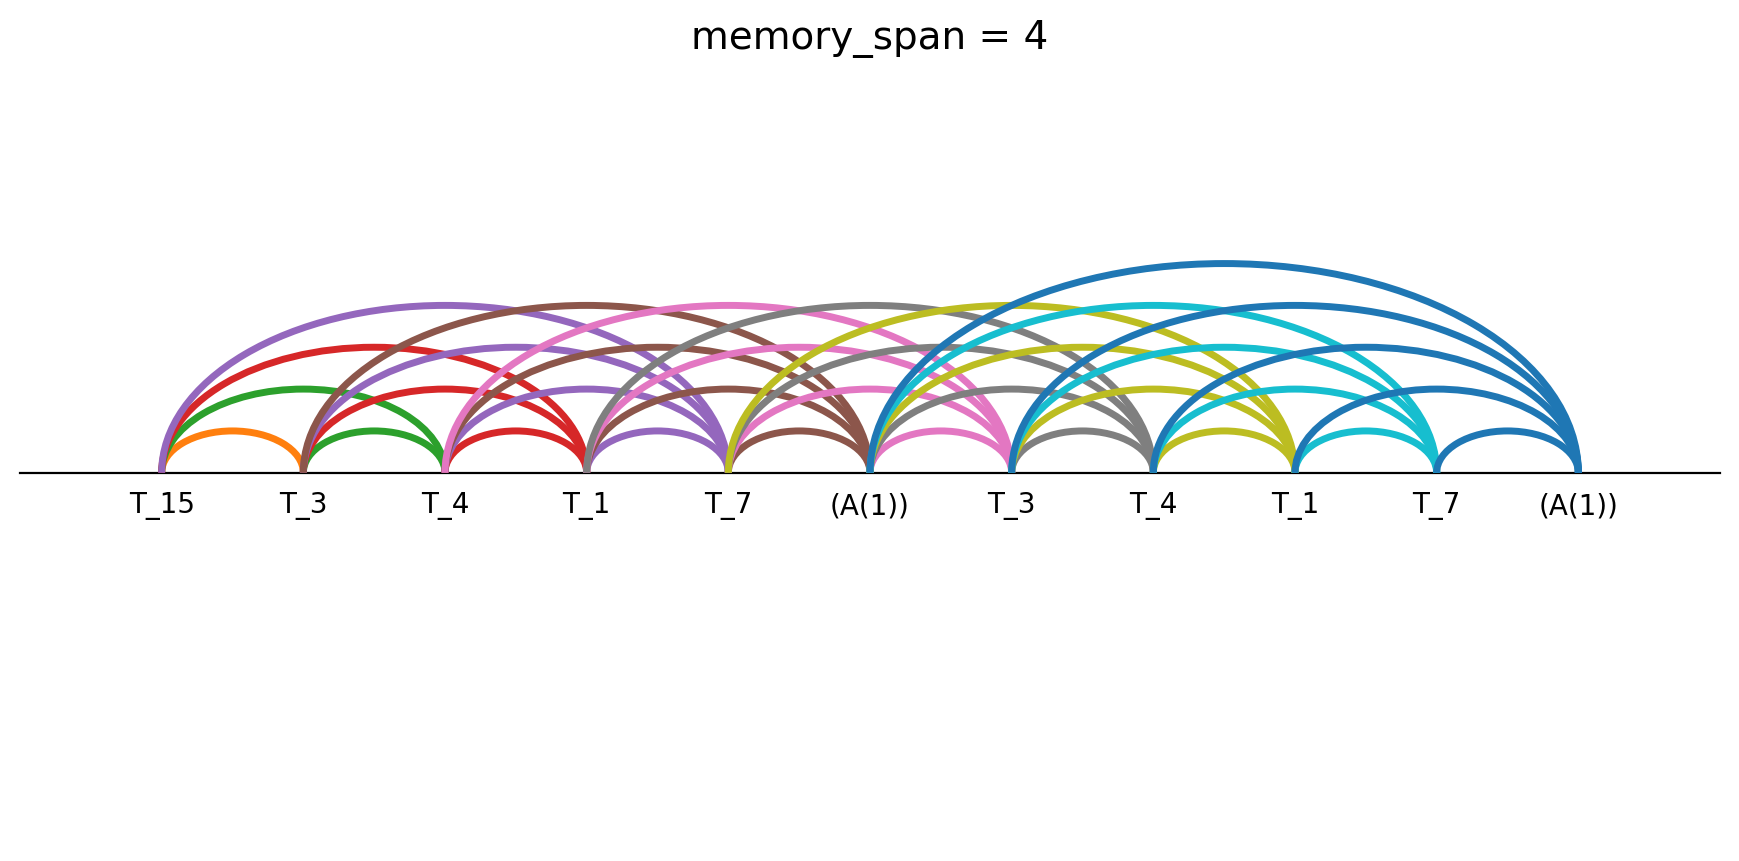

In [6]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title=f"memory_span = {memory_span}")


In [ ]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
from sorl.neo_utils import sorl_search_v2 

n = 2
K = 8
max_iterations=2
memory_span=1792
attn_blocksize=1792
temperature=10.0 

tokens = next(train_loader)

with torch.no_grad(): 
    search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature)

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
import torch 


# Prepare data - TEST WITH SMALLER SEQUENCE FIRST
tokens = next(train_loader)

# Run benchmark
results = run_benchmark_suite(
    model, 
    tokens, 
    memory_span=1024, 
    num_runs=10
)